このノートの内容は、下記でまとめている時系列データの予測をLightGBMで実行したものである。

- [Prophet で予測モデルの関数化(Python編)](https://sugiaki1989.github.io/statistical_note/note_prophet10/note_prophet10.ipynb)



In [ ]:
import logging
import warnings
from typing import Any, Dict, List, Optional, Tuple
import time
from datetime import datetime

import jpholiday
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# ----------------------------
# グローバル設定
# ----------------------------
# 特徴量作成用のパラメータ
LAGS = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 35, 42, 49]
WINDOWS = LAGS  # 同じ値を使用
EXPANSIONS = LAGS  # 同じ値を使用

# データ設定
START_DATE = '2018-07-01'
FORECAST_PERIODS = 7

# ----------------------------
# ログ設定
# ----------------------------
def setup_logging(level: str = "INFO") -> logging.Logger:
    """Setup optimized logging configuration"""
    # Clear existing handlers
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)
    
    # Custom formatter
    formatter = logging.Formatter(
        '%(asctime)s - %(levelname)s - %(message)s',
        datefmt='%H:%M:%S'
    )
    
    # Console handler
    console_handler = logging.StreamHandler()
    console_handler.setFormatter(formatter)
    console_handler.setLevel(getattr(logging, level))
    
    # File handler (optional)
    file_handler = logging.FileHandler(f'lightgbm_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
    file_handler.setFormatter(formatter)
    file_handler.setLevel(logging.DEBUG)
    
    # Logger configuration
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.DEBUG)
    logger.addHandler(console_handler)
    logger.addHandler(file_handler)
    
    # External library log level settings
    optuna.logging.set_verbosity(optuna.logging.ERROR)
    logging.getLogger('lightgbm').setLevel(logging.WARNING)
    logging.getLogger('sklearn').setLevel(logging.WARNING)
    
    return logger

# Initialize logging
logger = setup_logging("INFO")

# ----------------------------
# 1. データ読み込み・前処理（最適化）
# ----------------------------
def load_data(filepath: str, start_date: str = START_DATE) -> pd.DataFrame:
    """Load and preprocess data"""
    start_time = time.time()
    logger.info("Loading data from: %s", filepath)
    
    try:
        df = pd.read_csv(filepath)[['date', 'pageviews']].rename(columns={'date': 'ds', 'pageviews': 'y'})
        df['ds'] = pd.to_datetime(df['ds'])
        df = df[df['ds'] >= pd.to_datetime(start_date)]
        
        elapsed = time.time() - start_time
        logger.info("Data loading completed: %d rows (%.2f seconds)", len(df), elapsed)
        logger.debug("Data period: %s to %s", df['ds'].min(), df['ds'].max())
        
        return df
    except Exception as e:
        logger.error("Data loading error: %s", str(e))
        raise

# ----------------------------
# 2. 未来データ追加（最適化）
# ----------------------------
def add_future_dates(df: pd.DataFrame, periods: int = FORECAST_PERIODS) -> pd.DataFrame:
    """Add future dates for forecasting"""
    logger.info("Adding future dates: %d periods", periods)
    future_dates = pd.date_range(df['ds'].max() + pd.Timedelta(days=1), periods=periods)
    future_df = pd.DataFrame({'ds': future_dates, 'y': np.nan})
    logger.debug("Future data period: %s to %s", future_dates.min(), future_dates.max())
    return future_df

# ----------------------------
# 3. 特徴量作成（最適化）
# ----------------------------
def create_features(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """Create features for the model"""
    start_time = time.time()
    logger.info("Creating features")
    
    # Lag features
    logger.debug("Creating lag features...")
    for lag in LAGS:
        df[f'lag{lag}'] = df['y'].shift(lag)

    # Window features
    logger.debug("Creating window features...")
    for w in WINDOWS:
        df[f'win{w}'] = df['y'].shift(1).rolling(window=w, min_periods=1).mean()

    # Expanding features
    logger.debug("Creating expanding features...")
    for exp in EXPANSIONS:
        df[f'expan{exp}'] = df[f'lag{exp}'].expanding().mean()

    # Categorical features
    logger.debug("Creating categorical features...")
    df['weekday'] = df['ds'].dt.weekday
    weekday_dummies = pd.get_dummies(df['weekday'], prefix='wd', drop_first=False)
    df = pd.concat([df, weekday_dummies], axis=1)

    df['is_tuesday'] = df['ds'].dt.weekday == 1
    df['is_jholiday'] = df['ds'].apply(lambda x: jpholiday.is_holiday(x))

    feature_cols = [
        *[f'lag{l}' for l in LAGS],
        *[f'win{w}' for w in WINDOWS],
        *[f'expan{e}' for e in EXPANSIONS],
        *[f'wd_{i}' for i in range(7)],
        'is_tuesday',
        'is_jholiday'
    ]
    
    elapsed = time.time() - start_time
    logger.info("Feature creation completed: %d features (%.2f seconds)", len(feature_cols), elapsed)
    logger.debug("Feature list: %s", feature_cols[:10] + ['...'] if len(feature_cols) > 10 else feature_cols)
    
    return df, feature_cols

# ----------------------------
# 4. Optuna用Objective関数（最適化）
# ----------------------------
def _objective(trial: optuna.Trial, df: pd.DataFrame, feature_cols: List[str]) -> float:
    """Objective function for Optuna optimization"""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100)
    }
    
    cv_mae = []
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_idx, valid_idx) in enumerate(tss.split(df), 1):
        train_data = df.iloc[train_idx].copy()
        valid_data = df.iloc[valid_idx].copy()
        
        # Remove missing values
        train_data = train_data.dropna(subset=["y"] + feature_cols)
        valid_data = valid_data.dropna(subset=["y"] + feature_cols)
        
        if len(train_data) == 0 or len(valid_data) == 0:
            logger.warning("Fold %d: Skipping due to insufficient data", fold)
            continue

        model = LGBMRegressor(**params, verbose=-1)
        model.fit(train_data[feature_cols], train_data["y"])
        preds = model.predict(valid_data[feature_cols])
        
        mae = mean_absolute_error(valid_data["y"], preds)
        cv_mae.append(mae)
    
    avg_mae = np.mean(cv_mae) if cv_mae else float("inf")
    logger.debug("Trial %d - MAE: %.4f (CV: %s)", trial.number, avg_mae, [f"{m:.2f}" for m in cv_mae])
    return avg_mae

# ----------------------------
# 5. ハイパーパラメータチューニング（最適化）
# ----------------------------
def tune_hyperparameters(
    df: pd.DataFrame, feature_cols: List[str], n_trials: int = 100
) -> Dict[str, Any]:
    """Hyperparameter tuning using Optuna"""
    start_time = time.time()
    logger.info("Starting hyperparameter tuning: %d trials", n_trials)
    
    study = optuna.create_study(direction="minimize")
    study.optimize(
        lambda trial: _objective(trial, df, feature_cols), 
        n_trials=n_trials, 
        n_jobs=4,
        show_progress_bar=True
    )
    
    best_params = study.best_params
    best_score = study.best_value
    
    elapsed = time.time() - start_time
    logger.info("Hyperparameter tuning completed (%.2f seconds)", elapsed)
    logger.info("Best score: %.4f", best_score)
    logger.info("Best parameters: %s", best_params)
    
    return best_params

# ----------------------------
# 6. モデル構築（最適化）
# ----------------------------
def build_model(params: Dict[str, Any]) -> LGBMRegressor:
    """Build LightGBM model"""
    logger.info("Building LightGBM model")
    model = LGBMRegressor(**params, verbose=-1)
    logger.debug("Model parameters: %s", params)
    return model

# ----------------------------
# 7. 再帰的予測（最適化）
# ----------------------------
def recursive_forecast(
        df: pd.DataFrame, 
        model: LGBMRegressor, 
        feature_cols: List[str], 
        future_index: pd.Index,
        lags: List[int],
        windows: List[int],
        expansions: List[int]
    ) -> pd.DataFrame:
    """Perform recursive forecasting"""
    start_time = time.time()
    logger.info("Starting recursive forecast: %d steps", len(future_index))
    
    for i, idx in enumerate(future_index, 1):
        if i % 10 == 0:  # Progress update every 10 steps
            logger.debug("Forecast progress: %d/%d (%.1f%%)", i, len(future_index), i/len(future_index)*100)
        
        # Update lag features
        for lag in lags:
            full_idx = idx - lag
            if full_idx in df.index:
                df.at[idx, f"lag{lag}"] = (
                    df.at[full_idx, "yhat"] 
                    if pd.isna(df.at[full_idx, "y"]) 
                    else df.at[full_idx, "y"]
                )

        # Update window features
        for win in windows:
            lag_vals = []
            for j in range(idx - win + 1, idx + 1):
                if j in df.index and not pd.isna(df.at[j, f"lag{win}"]):
                    lag_vals.append(df.at[j, f"lag{win}"])
            df.at[idx, f"win{win}"] = np.mean(lag_vals) if lag_vals else np.nan

        # Update expanding features
        for expan in expansions:
            exp_vals = []
            for j in range(0, idx): # 0からidx-1までのデータを使用するため、j in df.indexの条件は不要
                if not pd.isna(df.at[j, f"lag{expan}"]):
                    exp_vals.append(df.at[j, f"lag{expan}"])
            df.at[idx, f"expan{expan}"] = np.mean(exp_vals) if exp_vals else np.nan

        # Make prediction
        input_row = df.loc[[idx], feature_cols]
        if not input_row.isna().any().any():
            prediction = model.predict(input_row)[0]
            df.at[idx, "yhat"] = prediction
    
    elapsed = time.time() - start_time
    logger.info("Recursive forecast completed (%.2f seconds)", elapsed)
    return df

# ----------------------------
# 8. 予測プロット関数（最適化）
# ----------------------------
def plot_forecast(df: pd.DataFrame, title: str = "Forecast plot") -> None:
    """Plot forecast results"""
    logger.info("Creating forecast plot")
    
    plt.figure(figsize=(14, 6))
    plt.plot(df["ds"], df["y"], label="Actual", color="gray", alpha=0.7)
    plt.plot(df["ds"], df["yhat"], label="Forecast", color="#006E4F")
    plt.axvline(
        pd.to_datetime("2019-09-01"), 
        color="gray", 
        linestyle="--", 
        alpha=0.7, 
        label="Forecast Start"
    )
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Pageviews")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True)
    plt.show()
    
    logger.debug("Plot display completed")

In [ ]:
# 1. Load data
df = load_data('../note_prophet09/data/GoogleAnalytics_TimeSeriesData.csv', start_date = START_DATE)

# 2. Add future dates
forecast_df = add_future_dates(df)
full_df = pd.concat([df, forecast_df], ignore_index=True)

# 3. Create features
full_df, feature_cols = create_features(full_df)
    
# 4. Prepare train/test data
train_test_df = full_df[full_df[feature_cols].notna().all(axis=1) & full_df["y"].notna()].copy()
train_df, test_df = train_test_split(train_test_df, test_size=62)

logger.info("Data preparation completed - Train: %d, Test: %d", len(train_df), len(test_df))

# 5. Hyperparameter tuning
best_params = tune_hyperparameters(train_df, feature_cols, n_trials = 500)
best_params

11:09:41 - INFO - Loading data from: ../note_prophet09/data/GoogleAnalytics_TimeSeriesData.csv
11:09:41 - INFO - Loading data from: ../note_prophet09/data/GoogleAnalytics_TimeSeriesData.csv
11:09:41 - INFO - Data loading completed: 427 rows (0.01 seconds)
11:09:41 - INFO - Data loading completed: 427 rows (0.01 seconds)
11:09:41 - INFO - Adding future dates: 7 periods
11:09:41 - INFO - Adding future dates: 7 periods
11:09:41 - INFO - Creating features
11:09:41 - INFO - Creating features
11:09:41 - INFO - Feature creation completed: 48 features (0.05 seconds)
11:09:41 - INFO - Feature creation completed: 48 features (0.05 seconds)
11:09:41 - INFO - Data preparation completed - Train: 316, Test: 62
11:09:41 - INFO - Data preparation completed - Train: 316, Test: 62


{'n_estimators': 491,
 'max_depth': 8,
 'learning_rate': 0.01077482468668965,
 'subsample': 0.8430295115468266,
 'colsample_bytree': 0.8044663472789777,
 'reg_alpha': 0.24085610653780937,
 'reg_lambda': 0.022732210461800656,
 'min_child_samples': 28}

11:09:41 - INFO - Building LightGBM model
11:09:41 - INFO - Building LightGBM model
11:09:42 - INFO - Test MAE: 118.4600
11:09:42 - INFO - Test MAE: 118.4600
11:09:42 - INFO - Creating forecast plot
11:09:42 - INFO - Creating forecast plot


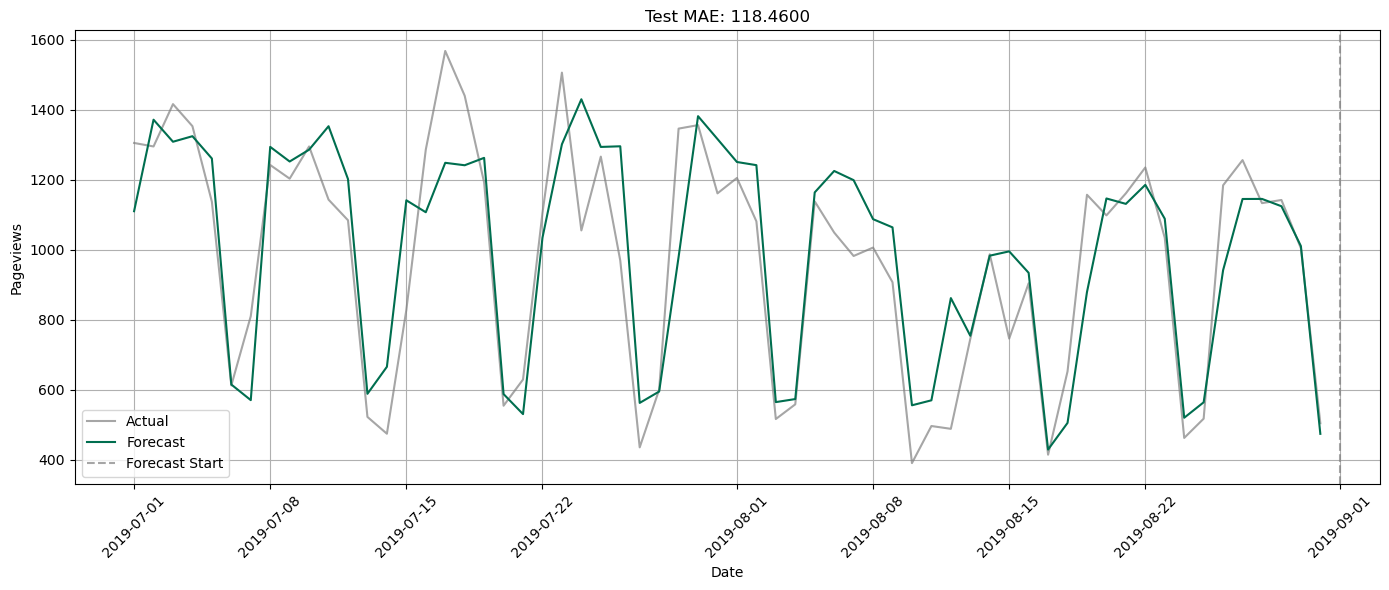

11:09:42 - INFO - Building LightGBM model
11:09:42 - INFO - Building LightGBM model
11:09:43 - INFO - Starting recursive forecast: 7 steps
11:09:43 - INFO - Starting recursive forecast: 7 steps
11:09:43 - INFO - Recursive forecast completed (0.16 seconds)
11:09:43 - INFO - Recursive forecast completed (0.16 seconds)
11:09:43 - INFO - Creating forecast plot
11:09:43 - INFO - Creating forecast plot


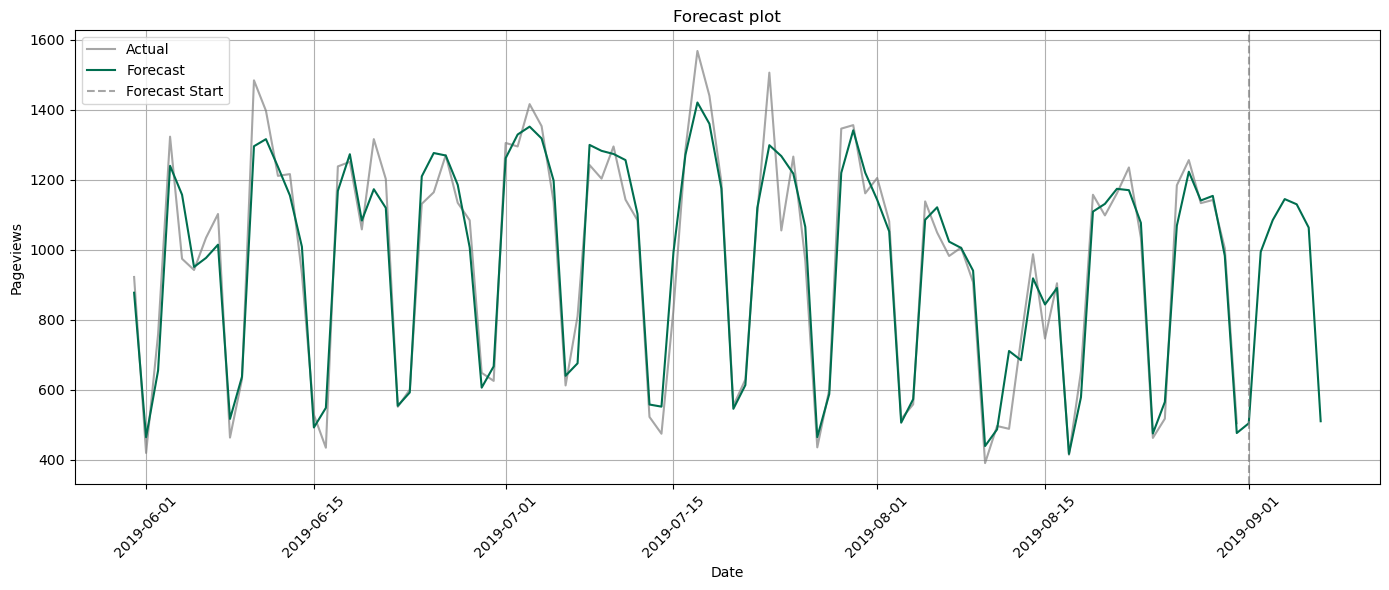

11:09:43 - INFO - Forecast pipeline completed successfully
11:09:43 - INFO - Forecast pipeline completed successfully


In [7]:
# 6. Build and train model
model = build_model(best_params)
train_data = train_df.dropna(subset=["y"] + feature_cols)
model.fit(train_data[feature_cols], train_data["y"])

# 7. Test predictions
test_data = test_df.dropna(subset=["y"] + feature_cols)
preds = model.predict(test_data[feature_cols])
test_data["yhat"] = preds
mae = mean_absolute_error(test_data["y"], preds)
logger.info("Test MAE: %.4f", mae)
plot_forecast(test_data, title=f"Test MAE: {mae:.4f}")

# 8. Full model training
full_model = build_model(best_params)
full_train_data = train_test_df.dropna(subset=["y"] + feature_cols)
full_model.fit(full_train_data[feature_cols], full_train_data["y"])

# 9. Recursive forecasting
future_index = full_df[full_df["y"].isna()].index
full_df = recursive_forecast(full_df, full_model, feature_cols, future_index, LAGS, WINDOWS, EXPANSIONS)
    
# 10. Prepare results
train_preds = full_model.predict(train_df[feature_cols])
train_df["yhat"] = train_preds

test_preds = full_model.predict(test_df[feature_cols])
test_df["yhat"] = test_preds
    
result_df = pd.concat([
    train_df[["ds", "y", "yhat"]],
    test_df[["ds", "y", "yhat"]],
    full_df.loc[future_index, ["ds", "y", "yhat"]],
    ]).sort_values("ds").tail(100)

# 11. Plot results
plot_forecast(result_df)
logger.info("Forecast pipeline completed successfully")